# The DataSmiths - IBM Employee Attrition Data Cleaning

In [45]:
import pandas as pd
import numpy as np

# Display all columns when viewing the dataset
pd.set_option("display.max_columns", None)

# Display more rows when necessary
pd.set_option("display.max_rows", 100)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import math


In [46]:
df = pd.read_csv("Dataset_IBM HR Analytics Employee Attrition & Performance.csv")

In [47]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [48]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


In [49]:
df.shape

(1470, 35)

### From the inspection above, we've got to know that there are 1,470 employee records and there are 35 variables.

In [50]:
#Checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Missing-Value Check

Missing values are checked for every column and for the dataset as a whole.

In [51]:
missing_values = df.isnull().sum()

missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [52]:
# Display only columns containing at least one missing value

columns_with_missing_values = missing_values[missing_values > 0]

if columns_with_missing_values.empty:
    print("No missing values were found.")
else:
    print(columns_with_missing_values)

No missing values were found.


### Cleaning decision

Because no missing values were found, we have decided that there is no need to:

* Drop any rows.
* Drop any columns.
* Fill any values with averages.
* Fill any values with modes.

## Duplicate-Record Check

Exact duplicate rows are identified before any records are removed.

In [53]:
df.duplicated().sum()

np.int64(0)

### Duplicate-Check decision

We found zero duplicated entries in the data. So, we move unto checking categorical values.

## Categorical-Value Check

Text-based categorical columns are inspected for extra spaces, inconsistent capitalisation and inconsistent labels.

In [54]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [55]:
# Count employees by attrition status
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [56]:
df["Gender"].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [57]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [58]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [59]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [60]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [61]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

In [62]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [63]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [64]:

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("Attrition")  # target, handle separately

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [65]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


### Final Checkings

In [66]:
df.shape

(1470, 32)

In [67]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.columns.duplicated().sum()

np.int64(0)

In [70]:
# Confirm that the intended columns were removed

removed_columns = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

for column in removed_columns:
    print(
        f"{column} present in cleaned dataset:",
        column in df.columns
    )

EmployeeCount present in cleaned dataset: False
Over18 present in cleaned dataset: False
StandardHours present in cleaned dataset: False
EmployeeNumber present in cleaned dataset: True


In [71]:
# Removes EmployeeNumber since it is not needed for analysis and is a unique identifier for each employee

if "EmployeeNumber" in df.columns:
    df = df.drop(columns=["EmployeeNumber"])
    print("EmployeeNumber has now been removed.")
else:
    print("EmployeeNumber was already removed.")

print("Current dataset shape:", df.shape)

EmployeeNumber has now been removed.
Current dataset shape: (1470, 31)


In [72]:
removed_columns = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

for column in removed_columns:
    print(
        f"{column} present in cleaned dataset:",
        column in df.columns
    )

EmployeeCount present in cleaned dataset: False
Over18 present in cleaned dataset: False
StandardHours present in cleaned dataset: False
EmployeeNumber present in cleaned dataset: False


In [73]:
print("EmployeeNumber" in df.columns)
print(df.shape)

False
(1470, 31)


In [74]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## Data Cleaning Decision Log

The following checks and cleaning decisions were completed:

1. The dataset was imported successfully.
2. An untouched copy of the original dataset was retained.
3. Column names were checked for unnecessary spaces.
4. Missing values were checked, and none were found.
5. Exact duplicate rows were checked, and none were found.
6. Leading, trailing and repeated spaces in categorical values were removed.
7. Categorical labels were inspected for inconsistencies.
8. Three constant columns were identified and removed:
   - `EmployeeCount`
   - `Over18`
   - `StandardHours`
9. `EmployeeNumber` was confirmed as a unique identifier and removed from the analytical dataset.
10. Numerical columns were checked for negative and impossible values.
11. The final cleaned dataset contains 1,470 rows and 31 columns.

# Exploratory Data Analysis (EDA)


Exploratory Data Analysis (EDA) is conducted to understand the distribution of the variables, identify patterns in the employee population, and examine the factors associated with employee attrition.

The analysis begins with the target variable, `Attrition`, before examining employee demographic, compensation, job-related, satisfaction, and career-related characteristics.

In [75]:
# Update the numerical and categorical column lists
# after removing unnecessary columns

num_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = df.select_dtypes(
    include="object"
).columns.tolist()

# Remove the target variable from the predictor list
if "Attrition" in cat_cols:
    cat_cols.remove("Attrition")

print("Number of numerical columns:", len(num_cols))
print("Number of categorical predictor columns:", len(cat_cols))

print("\nNumerical columns:")
print(num_cols)

print("\nCategorical predictor columns:")
print(cat_cols)

Number of numerical columns: 23
Number of categorical predictor columns: 7

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical predictor columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


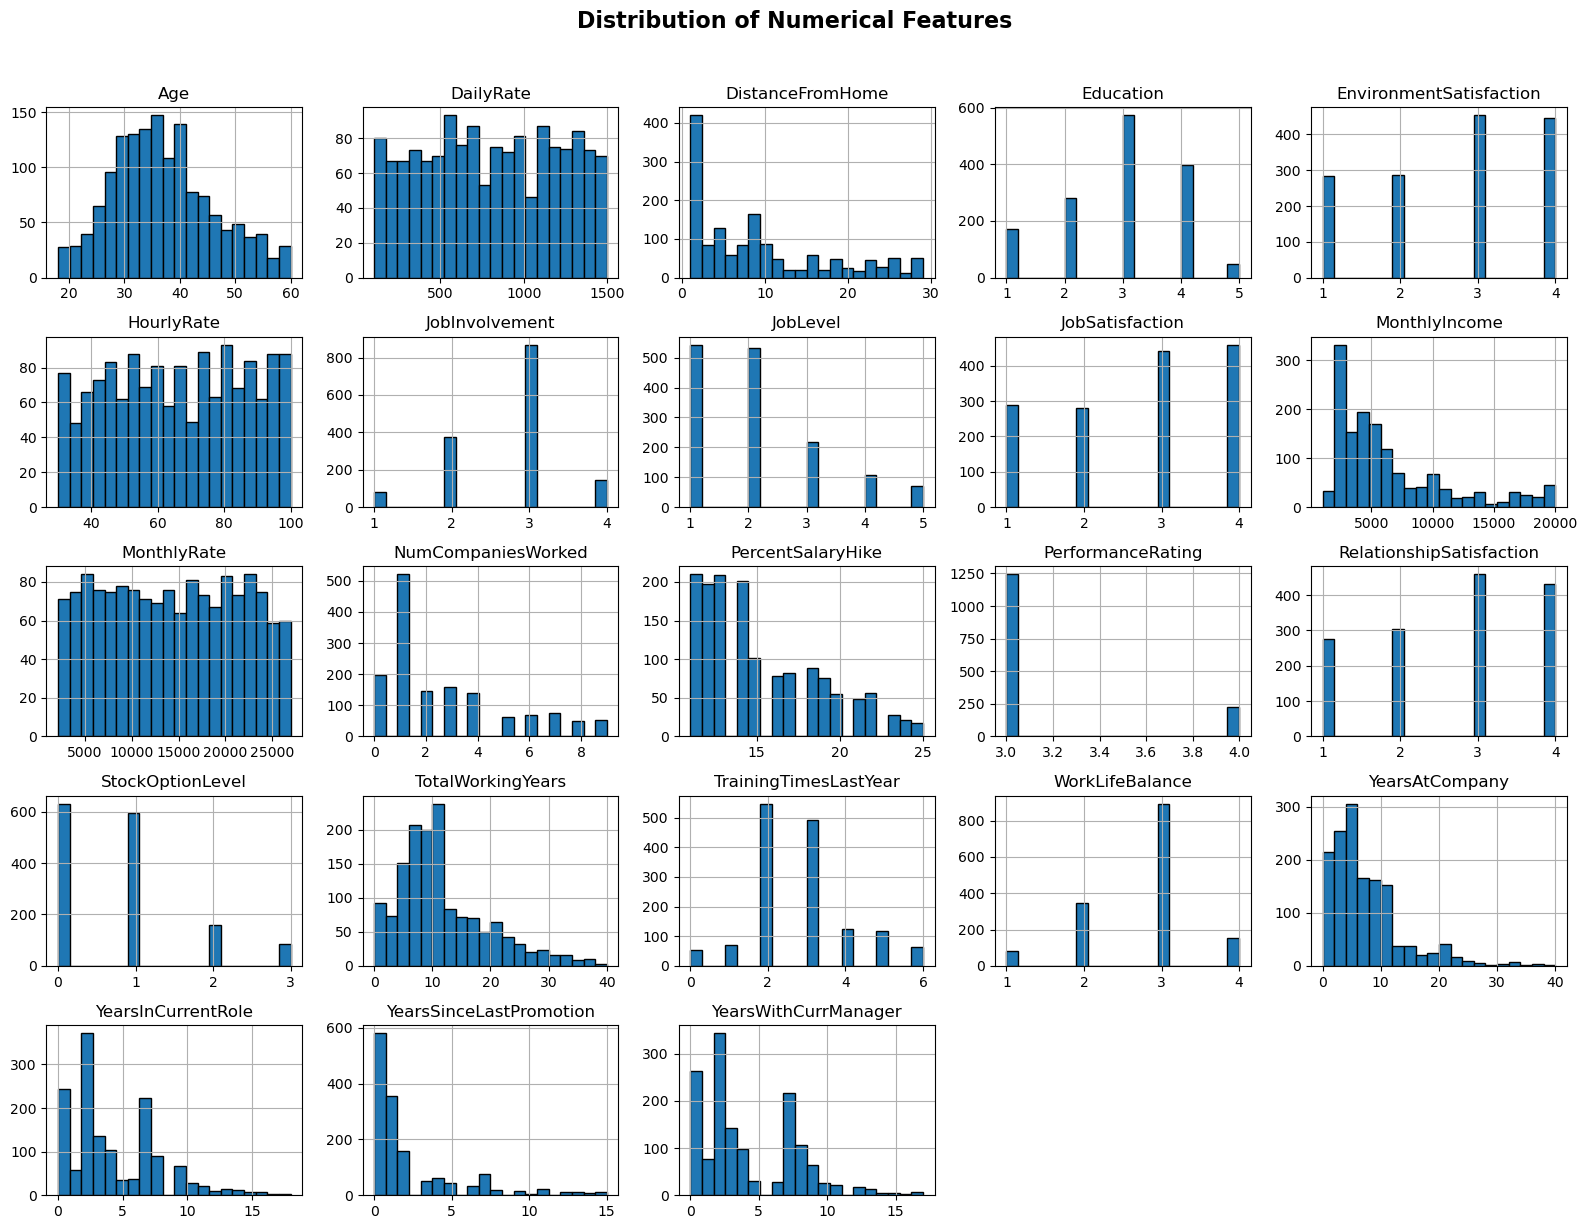

In [76]:
# Visual scan of every numerical column

df[num_cols].hist(
    figsize=(16, 12), bins=20, edgecolor="black")

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Initial Observation

The numerical-feature scan provides an overview of the distributions and ranges of the numerical variables. Several variables, such as monthly income, total working years, and years at the company, appear right-skewed, while satisfaction and rating variables take a limited number of ordinal values.

This preliminary scan is descriptive only. Further analysis is required to determine how these variables relate to employee attrition.

In [77]:
# Attrition rate by categorical features

for col in cat_cols:

    rate = (
        df.groupby(col)["Attrition"]
        .value_counts(normalize=True)
        .unstack()["Yes"]
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
    )

    print(f"\n--- Attrition Rate by {col} ---")
    print(rate.rename("Attrition Rate (%)"))


--- Attrition Rate by BusinessTravel ---
BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition Rate (%), dtype: float64

--- Attrition Rate by Department ---
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition Rate (%), dtype: float64

--- Attrition Rate by EducationField ---
EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition Rate (%), dtype: float64

--- Attrition Rate by Gender ---
Gender
Male      17.01
Female    14.80
Name: Attrition Rate (%), dtype: float64

--- Attrition Rate by JobRole ---
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Rep

### Categorical Feature Observations

The categorical analysis reveals several noticeable differences in attrition rates across employee groups.

- Employees who travelled frequently recorded an attrition rate of approximately **24.91%**, compared with **8.00%** among non-travelling employees.
- Employees working overtime had an attrition rate of approximately **30.53%**, compared with **10.44%** among employees who did not work overtime.
- Sales Representatives recorded the highest attrition rate among the job roles, at approximately **39.76%**.
- Single employees had a higher attrition rate of approximately **25.53%**, compared with **12.48%** for married employees and **10.09%** for divorced employees.
- The Sales and Human Resources departments recorded higher attrition rates than Research and Development.
- Male employees had a slightly higher attrition rate than female employees, although the difference was relatively small.

These results indicate associations within this dataset. They do not, by themselves, establish that any of these characteristics directly cause employee attrition.

# Numerical features versus Attrition

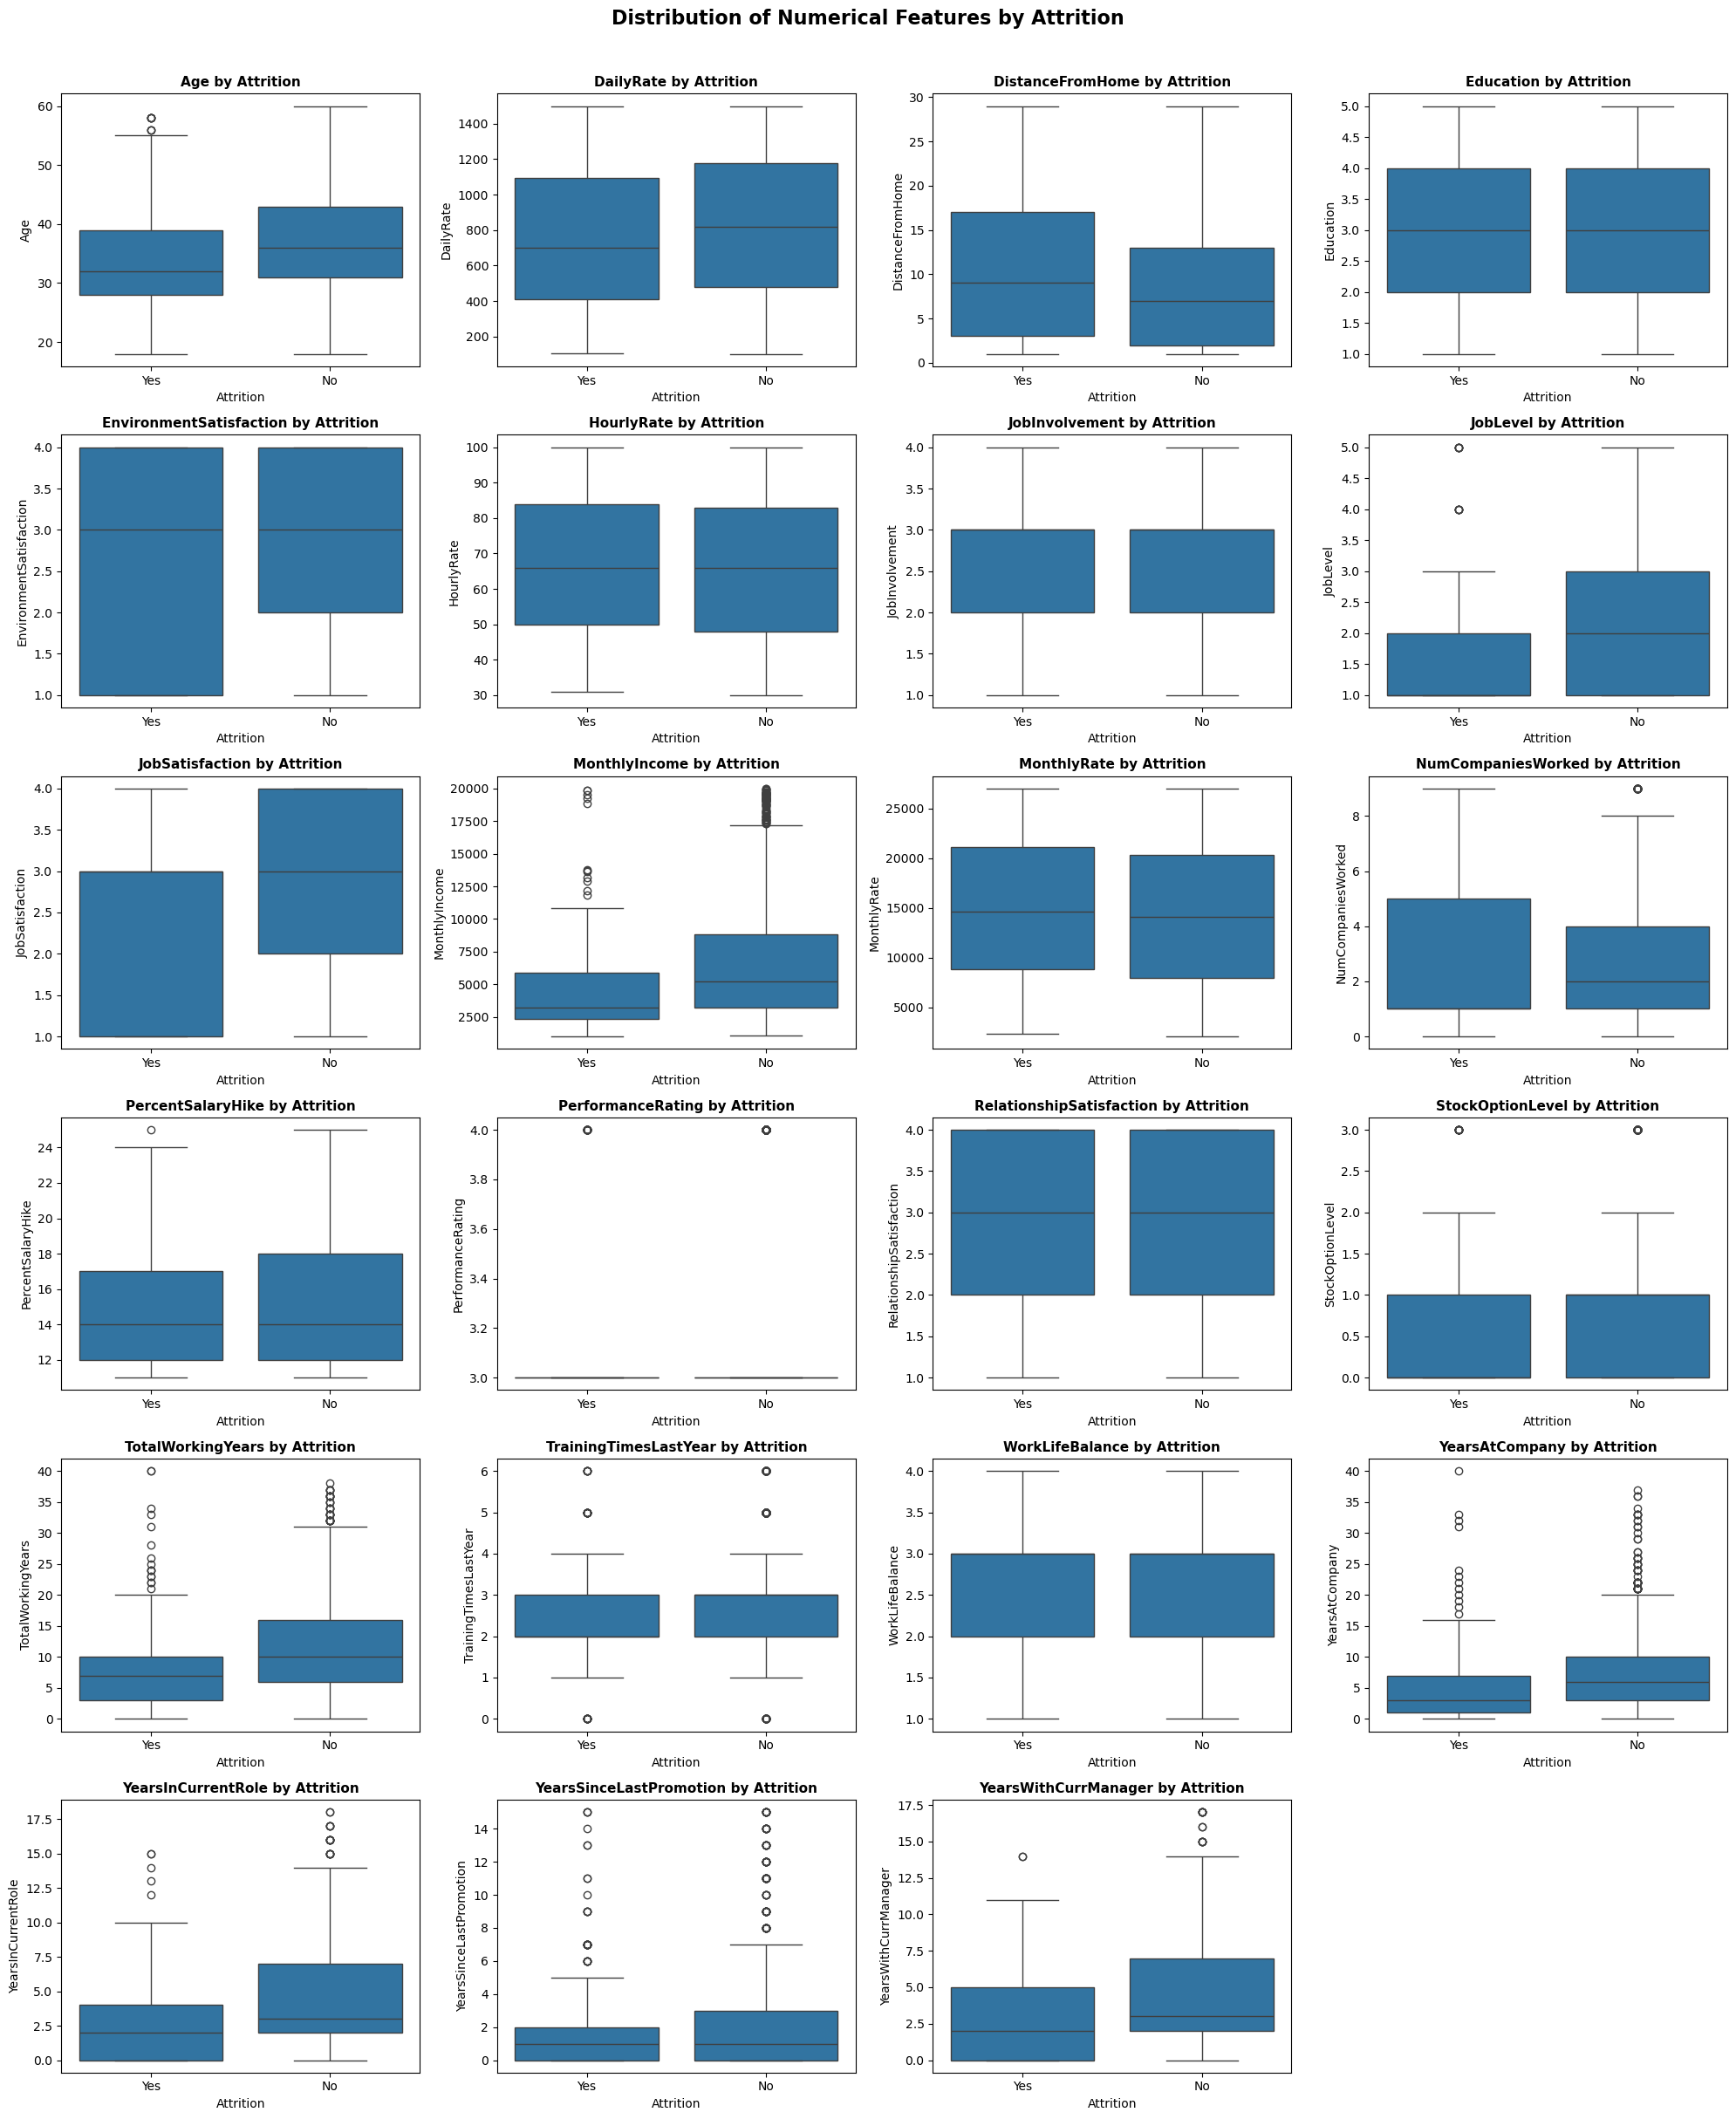

In [78]:
# Number of charts per row
charts_per_row = 4

# Calculate the number of rows required
number_of_rows = math.ceil(
    len(num_cols) / charts_per_row
)

fig, axes = plt.subplots(
    number_of_rows,
    charts_per_row,
    figsize=(20, number_of_rows * 4)
)

axes = axes.flatten()

# Create a boxplot for every numerical feature
for i, col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        x="Attrition",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col} by Attrition",
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("Attrition")
    axes[i].set_ylabel(col)

# Hide any unused subplot spaces
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Distribution of Numerical Features by Attrition",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

### Numerical Feature Observations

The boxplots compare the distributions of the numerical variables between employees who remained with the organisation and those who left.

Several visible patterns emerge:

- Employees who left generally appear younger than employees who remained.
- The attrition group tends to have lower monthly income.
- Employees who left generally have fewer total working years and fewer years at the company.
- The attrition group also appears to have spent fewer years in their current role and fewer years working with their current manager.
- Some variables, such as performance rating, show little visible difference between the two attrition groups.
- Considerable overlap remains between the groups for most numerical features, indicating that no single numerical variable completely explains employee attrition.

These visual differences represent associations within the dataset and should be examined further through grouped statistics and predictive modelling.

#Correlation heatmap

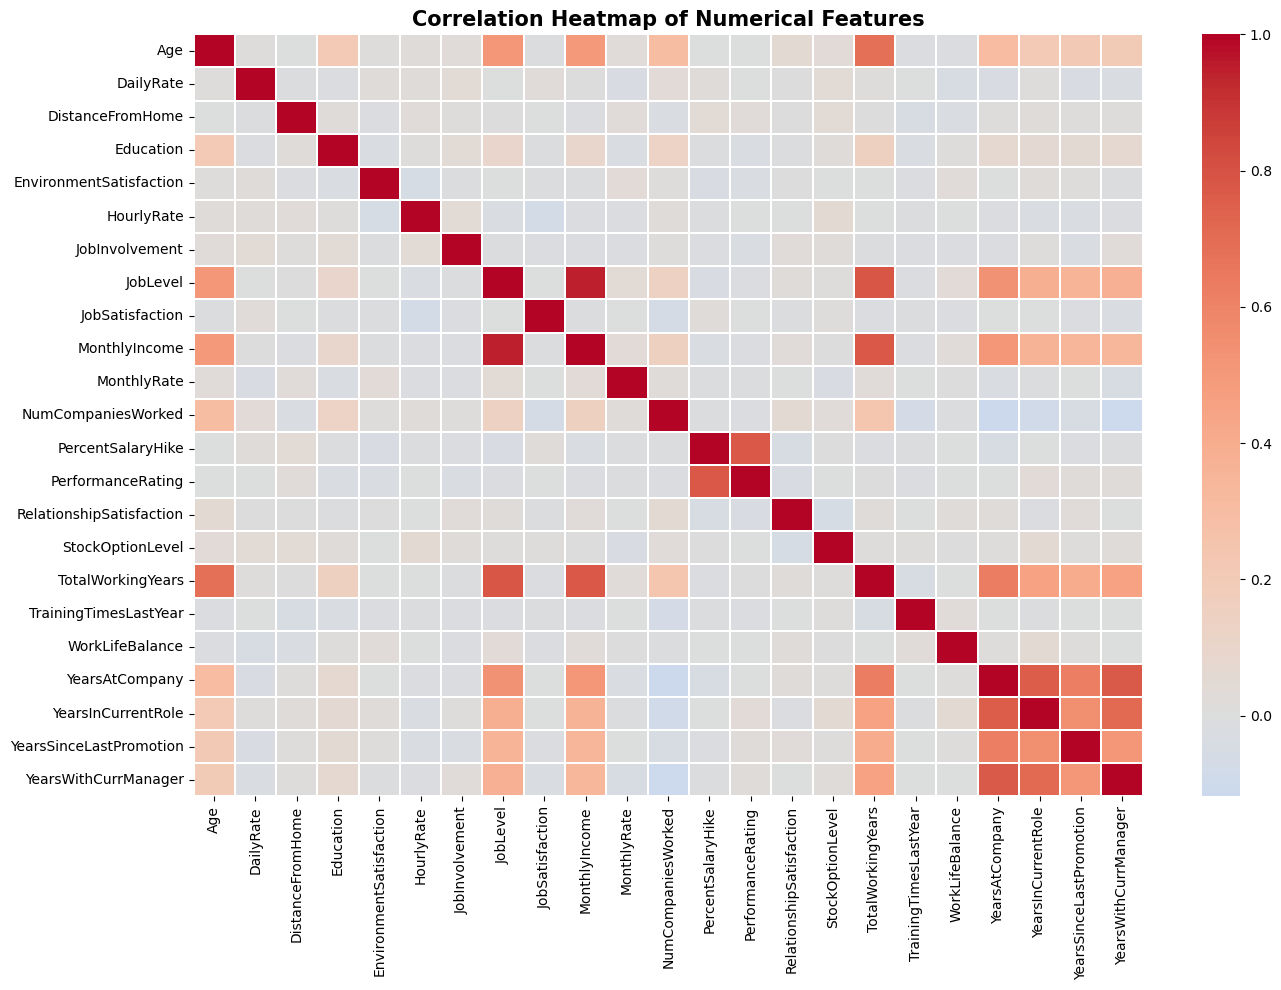

In [79]:
# Correlation heatmap for numerical features

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [80]:
# Create a temporary numerical version of Attrition
# No = 0, Yes = 1

attrition_numeric = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Create a temporary dataframe for correlation analysis

correlation_df = df[num_cols].copy()

correlation_df["AttritionNumeric"] = attrition_numeric

In [81]:
# Correlation of numerical features with Attrition

attrition_correlations = (
    correlation_df
    .corr()["AttritionNumeric"]
    .drop("AttritionNumeric")
    .sort_values()
)

attrition_correlations

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Name: AttritionNumeric, dtype: float64

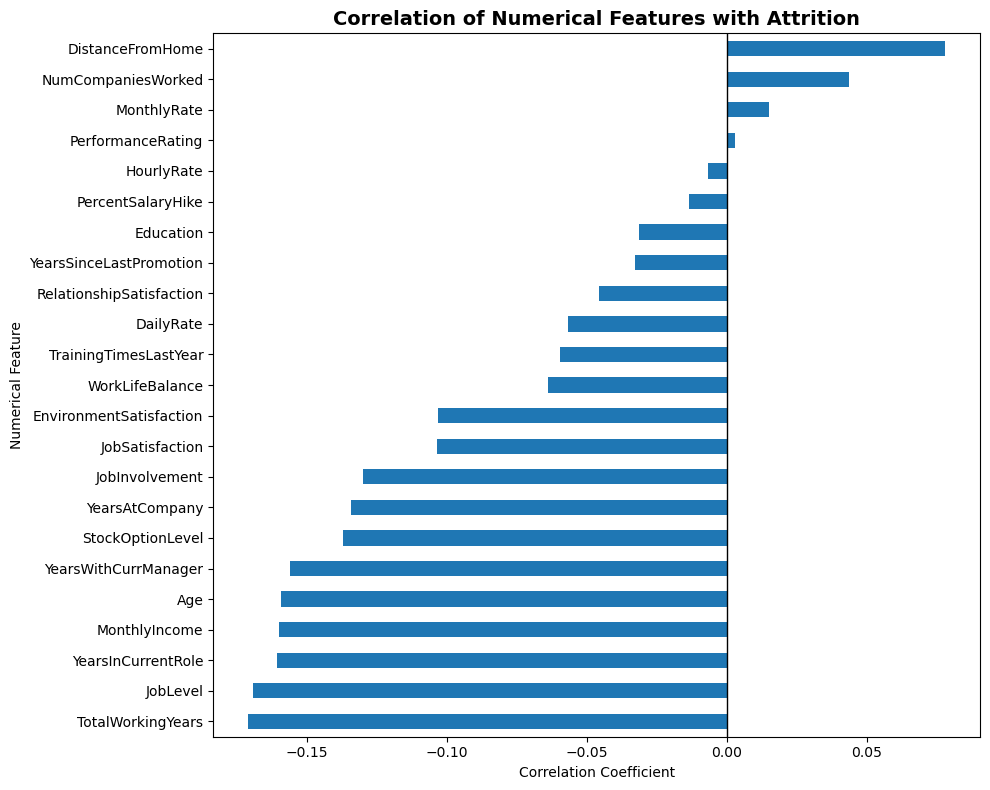

In [82]:
# Visualise numerical-feature correlations with Attrition

plt.figure(figsize=(10, 8))

attrition_correlations.sort_values().plot(
    kind="barh"
)

plt.title(
    "Correlation of Numerical Features with Attrition",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Numerical Feature")

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.tight_layout()
plt.show()

In [83]:
jobrole_overtime_rate = jobrole_overtime_rate.rename(
    columns={
        "No": "Stayed (%)",
        "Yes": "Attrition Rate (%)"
    }
)

jobrole_overtime_rate

NameError: name 'jobrole_overtime_rate' is not defined

In [ ]:
# Employee counts by Job Role, Overtime and Attrition

jobrole_overtime_counts = pd.crosstab(
    [df["JobRole"], df["OverTime"]],
    df["Attrition"]
)

jobrole_overtime_counts["Total Employees"] = (
    jobrole_overtime_counts.sum(axis=1)
)

jobrole_overtime_counts

Attrition                            No  Yes  Total Employees
JobRole                   OverTime                           
Healthcare Representative No         87    7               94
                          Yes        35    2               37
Human Resources           No         32    7               39
                          Yes         8    5               13
Laboratory Technician     No        166   31              197
                          Yes        31   31               62
Manager                   No         74    1               75
                          Yes        23    4               27
Manufacturing Director    No        100    6              106
                          Yes        35    4               39
Research Director         No         56    1               57
                          Yes        22    1               23
Research Scientist        No        181   14              195
                          Yes        64   33               97
Sales Executive           No        206   26              232
                          Yes        63   31               94
Sales Representative      No         42   17               59
                          Yes         8   16               24

In [ ]:
# Combine employee counts and attrition rates

jobrole_overtime_summary = (
    jobrole_overtime_counts
    .join(
        jobrole_overtime_rate[
            ["Attrition Rate (%)"]
        ]
    )
)

jobrole_overtime_summary

Attrition                            No  Yes  Total Employees  \
JobRole                   OverTime                              
Healthcare Representative No         87    7               94   
                          Yes        35    2               37   
Human Resources           No         32    7               39   
                          Yes         8    5               13   
Laboratory Technician     No        166   31              197   
                          Yes        31   31               62   
Manager                   No         74    1               75   
                          Yes        23    4               27   
Manufacturing Director    No        100    6              106   
                          Yes        35    4               39   
Research Director         No         56    1               57   
                          Yes        22    1               23   
Research Scientist        No        181   14              195   
                          Yes        64   33               97   
Sales Executive           No        206   26              232   
                          Yes        63   31               94   
Sales Representative      No         42   17               59   
                          Yes         8   16               24   

Attrition                           Attrition Rate (%)  
JobRole                   OverTime                      
Healthcare Representative No                      7.45  
                          Yes                     5.41  
Human Resources           No                     17.95  
                          Yes                    38.46  
Laboratory Technician     No                     15.74  
                          Yes                    50.00  
Manager                   No                      1.33  
                          Yes                    14.81  
Manufacturing Director    No                      5.66  
                          Yes                    10.26  
Research Director         No                      1.75  
                          Yes                     4.35  
Research Scientist        No                      7.18  
                          Yes                    34.02  
Sales Executive           No                     11.21  
                          Yes                    32.98  
Sales Representative      No                     28.81  
                          Yes                    66.67

In [ ]:
jobrole_overtime_summary.sort_values(
    by="Attrition Rate (%)",
    ascending=False
)

,Attrition,No,Yes,Total Employees,Attrition Rate (%)
JobRole,OverTime,,,,
Sales Representative,Yes,8,16,24,66.67
Laboratory Technician,Yes,31,31,62,50.00
Human Resources,Yes,8,5,13,38.46
Research Scientist,Yes,64,33,97,34.02
Sales Executive,Yes,63,31,94,32.98
Sales Representative,No,42,17,59,28.81
Human Resources,No,32,7,39,17.95
Laboratory Technician,No,166,31,197,15.74
Manager,Yes,23,4,27,14.81


### Job Role and Overtime Observations

The combined analysis of job role and overtime status shows that overtime is associated with considerably higher attrition in several job roles.

- Sales Representatives who worked overtime recorded the highest attrition rate, at approximately **66.67%**.
- Laboratory Technicians who worked overtime had an attrition rate of approximately **50.00%**, compared with **15.74%** among those who did not work overtime.
- Research Scientists who worked overtime recorded an attrition rate of approximately **34.02%**, compared with **7.18%** among those who did not.
- Sales Executives who worked overtime had an attrition rate of approximately **32.98%**, compared with **11.21%** among those who did not.
- Overtime did not affect every job role in exactly the same way, and some role-overtime groups contained relatively few employees.

The results suggest that overtime may be particularly associated with employee attrition in sales, laboratory, research, and human-resource roles. However, the group sizes should be considered when interpreting the percentages.

# Age Distribution and Attrition

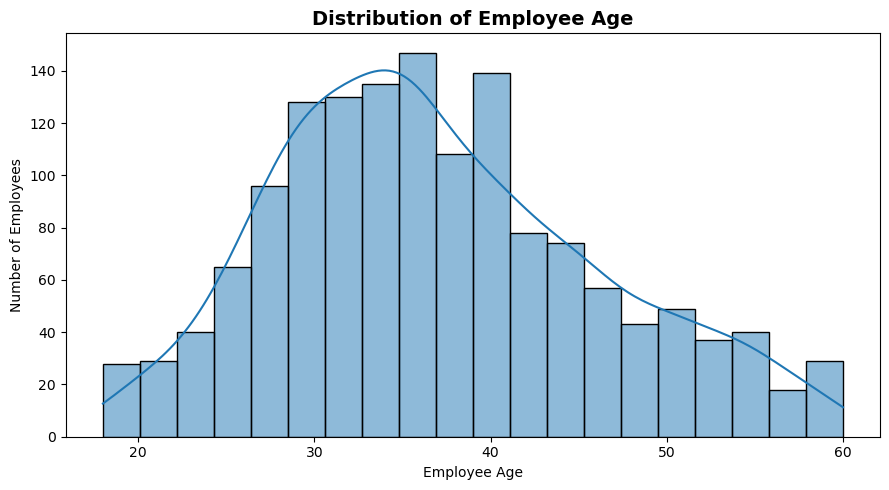

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
df["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

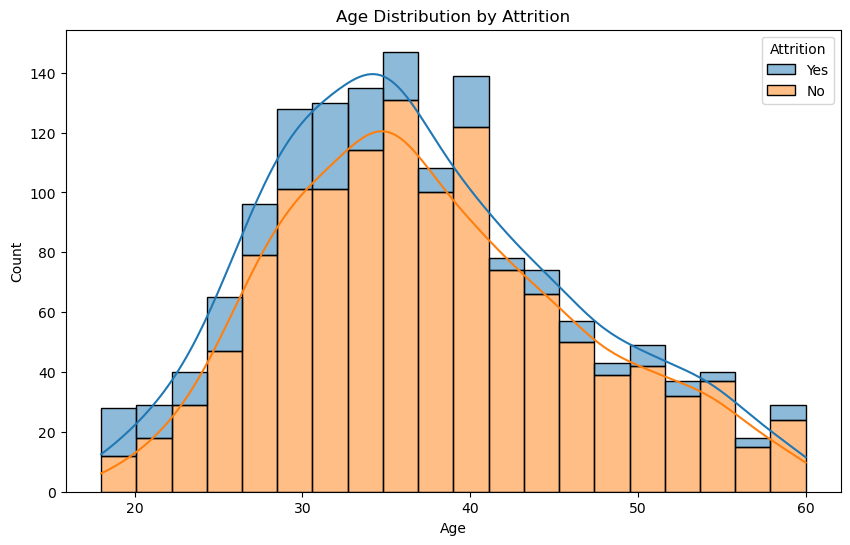

In [ ]:
#Distribution of employee ages
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, kde=True, multiple='stack')
plt.title('Age Distribution by Attrition')
plt.show()

In [ ]:
# Table of Attrition rate per Age bracket

age_attrition_table = (
    df.groupby(
        pd.cut(
            df["Age"],
            bins=[17, 25, 35, 45, 55, 60],
            labels=[
                "18–25",
                "26–35",
                "36–45",
                "46–55",
                "56–60"
            ],
            include_lowest=True
        ),
        observed=False
    )["Attrition"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

age_attrition_table

Attrition,No,Yes
Age,,
18–25,64.23,35.77
26–35,80.86,19.14
36–45,90.81,9.19
46–55,88.50,11.50
56–60,82.98,17.02


In [ ]:
age_attrition_table = age_attrition_table.rename(
    columns={
        "No": "Stayed (%)",
        "Yes": "Attrition Rate (%)"
    }
)

age_attrition_table

Attrition,Stayed (%),Attrition Rate (%)
Age,,
18–25,64.23,35.77
26–35,80.86,19.14
36–45,90.81,9.19
46–55,88.50,11.50
56–60,82.98,17.02


# Key Findings from Exploratory Data Analysis

The exploratory analysis identified several factors associated with employee attrition.

* The overall attrition rate was approximately 16.12%, showing that the target variable is imbalanced.
* Employees who worked overtime recorded a much higher attrition rate than those who did not.
* Frequent business travellers were more likely to leave than employees who travelled rarely or did not travel.
* Sales Representatives recorded the highest attrition rate among the job roles.
* Single employees had a higher attrition rate than married and divorced employees.
* Employees aged 18–25 recorded the highest attrition rate among the age groups.
* Employees who left generally had lower monthly income, fewer total working years, shorter organisational tenure, and fewer years in their current roles.
* Distance from home had a weak positive relationship with attrition, while performance rating showed little visible difference between employees who stayed and those who left.

Overall, employee attrition was associated with a combination of workload, travel frequency, job role, age, marital status, compensation, and career experience.

These findings show associations within the dataset and do not prove that any individual factor directly causes employees to leave.


# Feature Engineering and Encoding

Feature engineering and encoding are important preprocessing steps in machine learning. Feature engineering involves selecting, transforming, or creating variables that may improve model performance, while encoding converts categorical variables into numerical representations that machine-learning algorithms can process.

The dataset was already well structured and required minimal additional feature engineering. Therefore, this section focuses mainly on preparing the target and categorical predictor variables for model development.

In [ ]:
# Create a copy of the cleaned dataset for feature engineering

df_fe = df.copy()

print("Feature-engineering copy created.")
print("Dataset shape:", df_fe.shape)

Feature-engineering copy created.
Dataset shape: (1470, 31)


## Feature Selection

The constant columns and the unique employee identifier were removed during data cleaning. Following the exploratory analysis, all remaining variables were retained because they may provide useful information for predicting employee attrition.

No additional columns were removed at this stage.


In [ ]:
df_fe.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

## Identifying Numerical and Categorical Variables

In [ ]:
# Identify the target variable

target_column = "Attrition"

# Identify categorical predictor variables

categorical_cols = (
    df_fe
    .drop(columns=[target_column])
    .select_dtypes(include="object")
    .columns
    .tolist()
)

# Identify numerical predictor variables

numerical_cols = (
    df_fe
    .drop(columns=[target_column])
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print("Target variable:")
print(target_column)

print("\nCategorical predictor variables:")
print(categorical_cols)

print("\nNumerical predictor variables:")
print(numerical_cols)

print("\nNumber of categorical predictors:", len(categorical_cols))
print("Number of numerical predictors:", len(numerical_cols))

Target variable:
Attrition

Categorical predictor variables:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical predictor variables:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Number of categorical predictors: 7
Number of numerical predictors: 23


## Encoding Categorical Variables

Machine-learning algorithms require numerical input. Therefore, the categorical target and predictor variables must be converted into numerical representations.

### Binary Encoding

The target variable, `Attrition`, and the binary predictors, `Gender` and `OverTime`, each contain two categories. They are converted into binary values using clearly defined mappings.


In [ ]:
# Define clear binary mappings

binary_mappings = {
    "Attrition": {
        "No": 0,
        "Yes": 1
    },
    "Gender": {
        "Female": 0,
        "Male": 1
    },
    "OverTime": {
        "No": 0,
        "Yes": 1
    }
}

# Apply the mappings

for column, mapping in binary_mappings.items():
    df_fe[column] = df_fe[column].map(mapping)

print("Binary variables encoded successfully.")

Binary variables encoded successfully.


**Verify Encoding**

In [ ]:
df_fe[['Attrition','Gender','OverTime']].head()

,Attrition,Gender,OverTime
0,1,0,1
1,0,1,0
2,1,1,1
3,0,0,1
4,0,1,0


In [ ]:
# Confirm the unique encoded values

for column in ["Attrition", "Gender", "OverTime"]:
    print(
        f"{column}:",
        sorted(df_fe[column].unique())
    )

Attrition: [np.int64(0), np.int64(1)]
Gender: [np.int64(0), np.int64(1)]
OverTime: [np.int64(0), np.int64(1)]


## One-Hot Encoding

The remaining categorical predictor variables contain more than two categories. Applying ordinary numerical labels to these variables could introduce an artificial order among categories that have no natural ranking.

Therefore, one-hot encoding was used to create separate binary indicator columns for the categories.


In [ ]:
# Identify categorical predictors with more than two categories

multi_class_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus"
]

# Apply one-hot encoding

df_fe = pd.get_dummies(
    df_fe,
    columns=multi_class_cols,
    drop_first=True,
    dtype=int
)

print("One-hot encoding completed successfully.")
print("Encoded dataset shape:", df_fe.shape)

One-hot encoding completed successfully.
Encoded dataset shape: (1470, 45)


In [84]:
# Identify Boolean columns

boolean_cols = df_fe.select_dtypes(
    include="bool"
).columns

# Convert Boolean columns to integers

df_fe[boolean_cols] = df_fe[boolean_cols].astype(int)

print(
    f"{len(boolean_cols)} Boolean columns converted to integers."
)

0 Boolean columns converted to integers.


## Verify Encoded Dataset

In [85]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [86]:
df_fe.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0


The dataset was successfully transformed into a fully numerical format suitable for machine learning algorithms. Binary variables were encoded using Label Encoding, while multi-class categorical variables were converted using One-Hot Encoding.

In [87]:
# Verify that the encoded dataset is fully numerical

remaining_categorical_cols = (
    df_fe.select_dtypes(include="object")
    .columns
    .tolist()
)

print("Dataset shape:", df_fe.shape)
print("Missing values:", df_fe.isnull().sum().sum())
print("Duplicate column names:", df_fe.columns.duplicated().sum())
print("Remaining object columns:", remaining_categorical_cols)

Dataset shape: (1470, 45)
Missing values: 0
Duplicate column names: 0
Remaining object columns: []


In [90]:
# Confirm the encoded target distribution

df_fe["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### Encoding Summary

The dataset was successfully transformed into a fully numerical format suitable for machine-learning algorithms.

The target variable and binary predictors were encoded using explicit mappings, while the remaining multi-category predictors were transformed using one-hot encoding.

The encoded dataset contains **1,470 employee records and 45 columns**, with no missing values or remaining text-based variables.
